## Setup

In [1]:
import random
import networkx as nx
import torch
import torch.nn as nn

from deep_ebm.utils_ebm import show_graph, evaluate_model
from deep_ebm.utils_ebm import save_graph, compare_graphs, show_graph_grid, compare_statistics
from deep_ebm.gnn_ebm import GraphDataset, GNN_EBM, train_one_epoch_pcd, gibbs_ministeps, evaluate_mmd_generated

from src.torch_erg import load_pglib_opf as lp
from src.torch_erg.samplers import GWGSampler, MHSampler, GWG_Hybrid_Sampler, MH_Hybrid_Sampler
from src.torch_erg.utils import laplacian_matrix,  unif_move, index_ravel_sampler
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle as pkl
from scipy.sparse.csgraph import connected_components
from scipy.sparse import csr_matrix

from Plots_and_utils.plots import *
from Plots_and_utils.other_g_stats import *

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
from src.torch_erg.utils import laplacian_matrix
from src.torch_erg.samplers import MHSampler_Hard

class Measurer(MHSampler_Hard):
    def __init__(self, backend: str):
        super().__init__(backend)

    def observables(self,mtx):
        L = laplacian_matrix(mtx)
        a3 = torch.matmul(torch.matmul(mtx,mtx),mtx)

        edges = torch.sum(mtx)/2
        triangles = torch.trace(a3)/6
        ac = torch.linalg.eigvalsh(L)[1]
        deg = torch.diagonal(L)
        tri_diag = torch.diagonal(a3) / 2

        valid = deg > 1
        local_clust = torch.zeros_like(deg)
        local_clust[valid] = tri_diag[valid] / (deg[valid] * (deg[valid] - 1))
        avg_clustering = torch.mean(local_clust[valid])

        avg_degree = torch.sum(mtx, dim=1).mean()

        return(torch.stack([edges, triangles, ac, avg_degree, avg_clustering]))

measurer = Measurer(backend='cpu')

In [3]:
with open("Saved_models/2community_GNN_EBM_50e_2000GS.pkl", "rb") as f:
    model_deep= pkl.load(f)

In [4]:
with open("data/TOY2community_dataset/TOY2comms_GraphDataset.pkl", "rb") as f:
    dataset_2community = pkl.load(f)

dataset_obs = [measurer.observables(g[0]) for g in dataset_2community]
torch.stack(dataset_obs).mean(axis = 0)

tensor([1.0603e+02, 1.1354e+02, 1.0209e-01, 7.0687e+00, 2.4433e-01])

In [5]:
reference = dataset_2community[0][0]
ref_feats = dataset_2community[0][1]

In [6]:
model_deep(ref_feats, reference)

tensor(188.6816, grad_fn=<SqueezeBackward0>)

---

In [ ]:
class HybridSampler(GWG_Hybrid_Sampler):
    #def __init__(self, backend: str, model: nn.Module):
        #super().__init__(backend, model)
        #self.model = model
        #self.model.to_device()

    def observables(self, mtx):
        edges = torch.sum(mtx)/2
        triangles = torch.trace(torch.matmul(torch.matmul(mtx,mtx),mtx))/6
        return(torch.stack([edges, triangles]))

#we freeze the node features as we do not need them, so that we can evaluate the model only on the adj matrix
class NoFeatModel(nn.Module):
    def __init__(self, model, feats):
        super().__init__()
        self.model = model
        self.feats = feats.to(device)

    def forward(self,adj):
        return(self.model(self.feats, adj))

In [9]:
# Initial parameters
betas = torch.tensor([0., 0.])
weight_deep = 1
weight_erg = 1
niter_params = 500000
niter_sampling = 100000
params_update_every = 3
alpha = 0.001
min_change = 0.001

In [10]:
adj_model = NoFeatModel(model_deep, ref_feats)

sampler = HybridSampler(backend="cpu",model = adj_model)
obs = sampler.observables(reference)
print("Reference observables: ", obs)
reference = reference.to(device)

Reference observables:  tensor([109., 127.])


In [18]:
params_only_deep = torch.tensor([0., 0.])

observables_deep, graphs_deep = sampler.sample_run(graph=reference,
                      observables=obs,
                      params=params_only_deep,
                      niter=niter_sampling,
                      save_every=50,
                      burn_in=0.2)

100%|██████████| 100000/100000 [05:37<00:00, 296.47it/s]

number of accepted steps is:  47077
number of rejected samples:  52923
Graph sampled:  1718
-----------------------------------
Start obs:  tensor([109., 127.])
Mean obs:  tensor([110.0518, 122.5035])


In [12]:
# Small tailoring
params, _ = sampler.param_run(graph=reference,
                      observables=torch.Tensor([100, 100]),
                      params=betas,
                      niter=niter_params,
                      params_update_every=params_update_every,
                      save_every=50,
                      save_params=True,
                      alpha=alpha,
                      min_change=min_change)

100%|██████████| 500000/500000 [31:14<00:00, 266.74it/s] 

number of accepted steps is:  242842
number of rejected samples:  257158
number of effective updates is:  80947


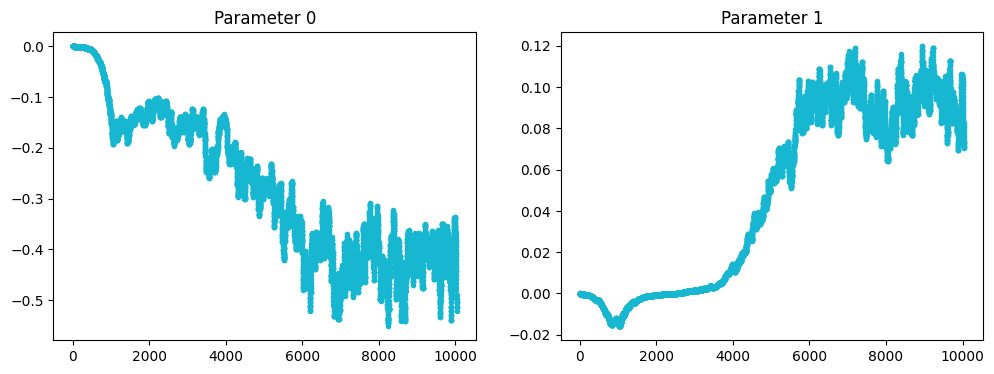

In [13]:
plot_params_iterations(params)

In [14]:
params_for_estimates = torch.stack(params[-1000:]).mean(axis = 0)
params_for_estimates

tensor([-0.4150,  0.0938])

In [21]:
observables_sampled, graphs_sampled = sampler.sample_run(graph=reference,
                      observables=obs,
                      params=params_for_estimates,
                      niter=100000,
                      save_every=50,
                      burn_in=0.2)

100%|██████████| 100000/100000 [06:14<00:00, 267.34it/s]

number of accepted steps is:  52233
number of rejected samples:  47767
Graph sampled:  1580
-----------------------------------
Start obs:  tensor([109., 127.])
Mean obs:  tensor([112.4652, 151.1741])


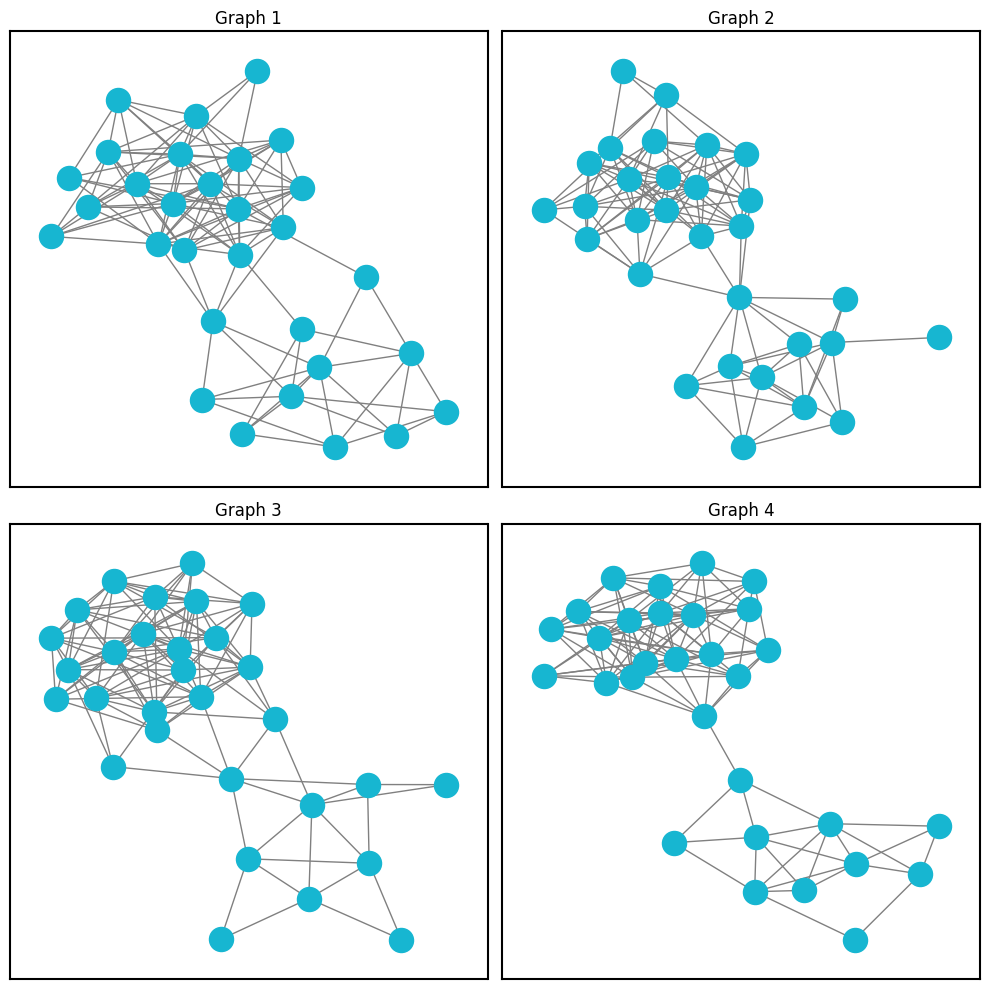

In [31]:
plot_random_graphs(graphs_sampled)

In [22]:
only_deep_obs = [measurer.observables(g) for g in graphs_deep]
generated_obs = [measurer.observables(g) for g in graphs_sampled]

In [36]:
torch.stack(dataset_obs).mean(dim = 0), torch.stack(dataset_obs).std(dim=0)

(tensor([1.0603e+02, 1.1354e+02, 1.0209e-01, 7.0687e+00, 2.4433e-01]),
 tensor([7.4799e+00, 2.5325e+01, 6.4490e-03, 4.9866e-01, 2.4399e-02]))

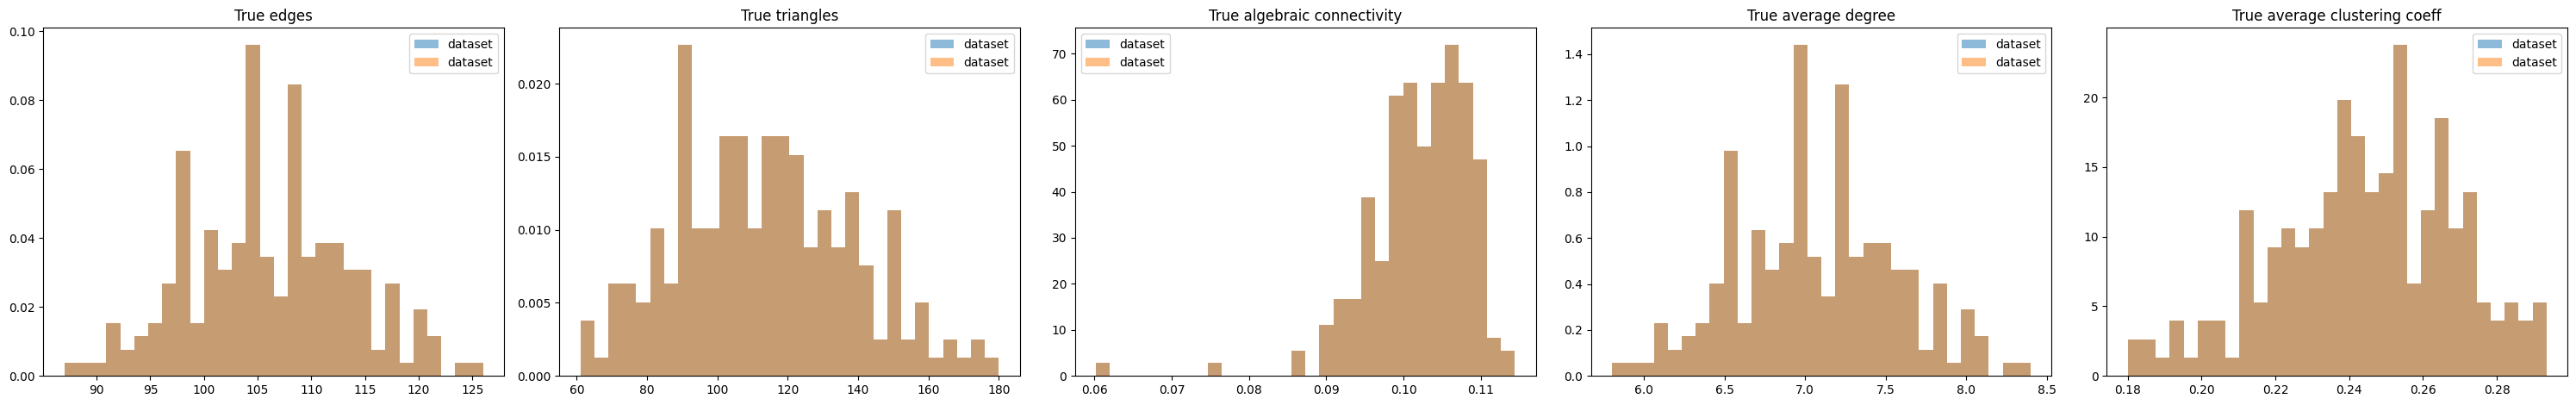

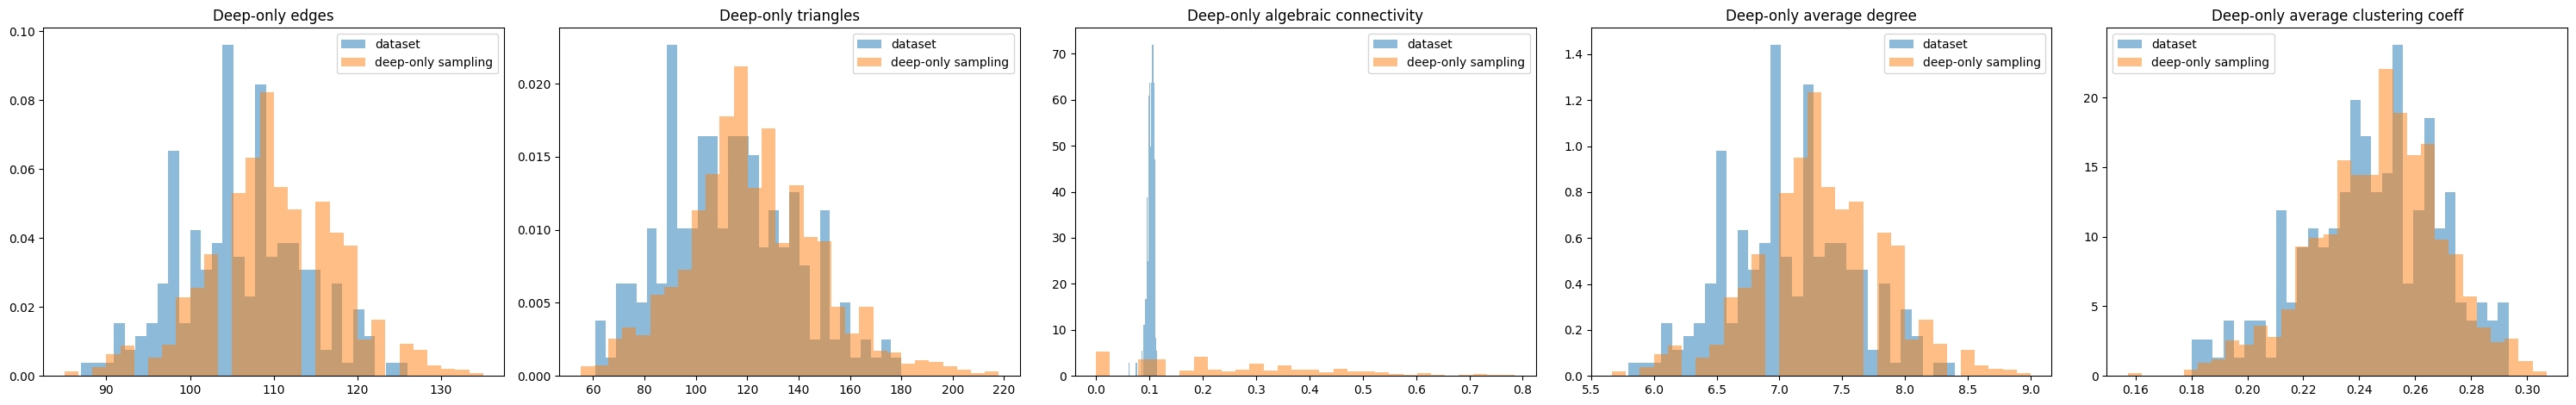

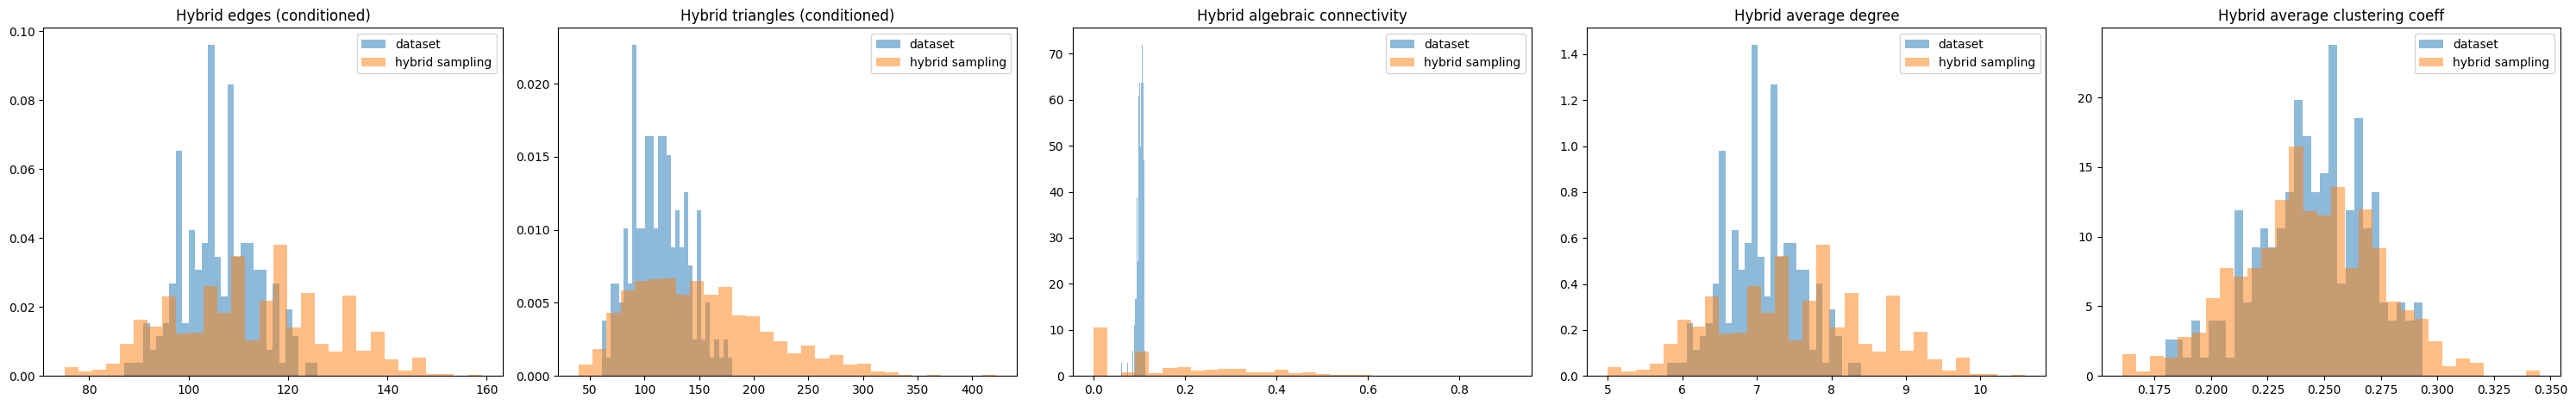

In [30]:
hist_comparison(dataset_obs,dataset_obs, obs_labels=['True edges', 'True triangles', 'True algebraic connectivity', 'True average degree', 'True average clustering coeff'], distributions_labels=["dataset", "dataset"])
hist_comparison(dataset_obs, only_deep_obs, obs_labels=['Deep-only edges', 'Deep-only triangles', 'Deep-only algebraic connectivity', 'Deep-only average degree', 'Deep-only average clustering coeff'], distributions_labels=["dataset", "deep-only sampling", ])
hist_comparison(dataset_obs, generated_obs, obs_labels=['Hybrid edges (conditioned)', 'Hybrid triangles (conditioned)', 'Hybrid algebraic connectivity', 'Hybrid average degree', 'Hybrid average clustering coeff'], distributions_labels=["dataset", "hybrid sampling"])

---

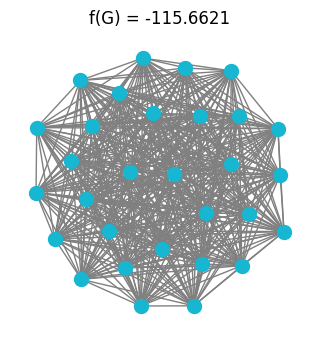

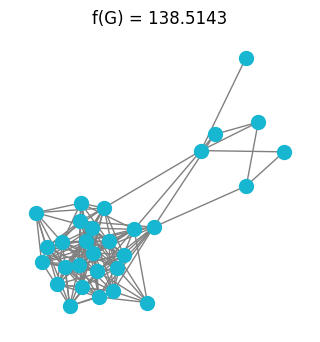

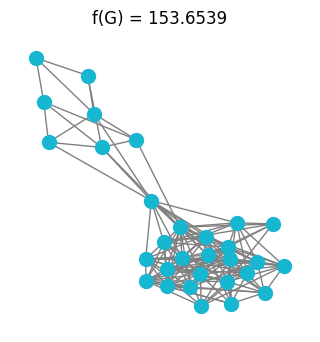

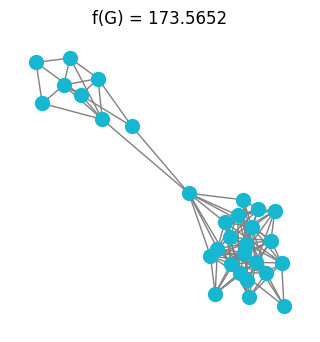

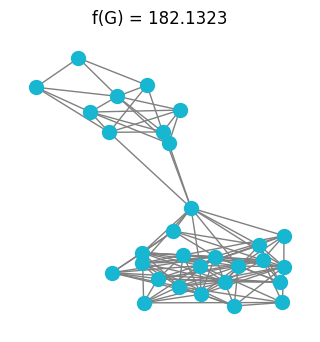

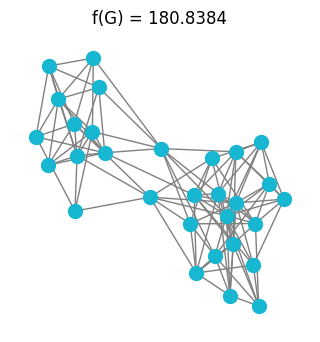

In [47]:
its = 100000
plot_every = 20000

energies_iterations = []

A, feats = dataset_2community[0]
A = torch.Tensor(nx.to_numpy_array(nx.binomial_graph(30, 1)))

energy = model_deep(feats, A)
for i in range(its):
    A = gibbs_ministeps(A, model_deep, feats.to(device), device, mini_steps=1)
    energy = model_deep(feats, A)
    if i % plot_every == 0 or i == its - 1:
        plot_graph(A, w = 3, h = 3, node_size=100, title=f"f(G) = {energy:.4f}")
    energies_iterations.append(energy.item())

---

In [63]:
# if the deep only model produces [111.4257, 126.2503], test on a lower number of edges constraint
new_ref_obs = torch.Tensor([100., 100.])

In [65]:

params2, _ = sampler.param_run(graph=reference,
                      observables= new_ref_obs,
                      params=betas,
                      niter=1500000,
                      params_update_every=params_update_every,
                      save_every=50,
                      save_params=True,
                      alpha=alpha,
                      min_change=min_change)


100%|██████████| 1500000/1500000 [1:30:43<00:00, 275.56it/s]

number of accepted steps is:  734968
number of rejected samples:  765032
number of effective updates is:  244989


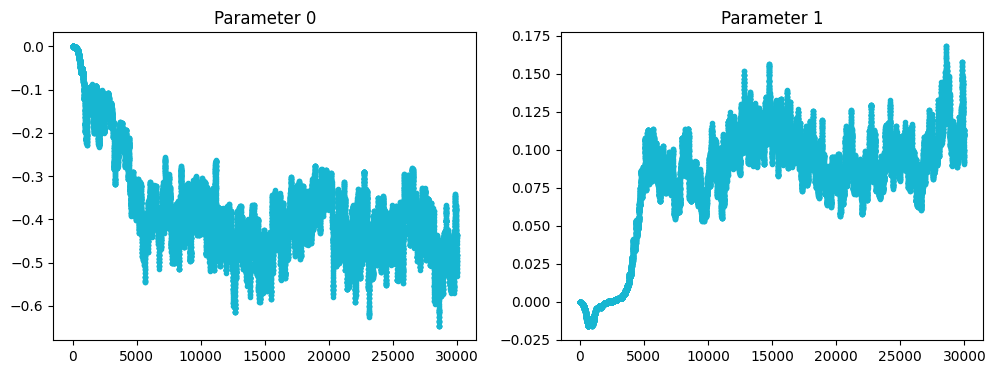

In [66]:
plot_params_iterations(params2)

In [67]:
params_for_estimates2 = torch.stack(params2[-10000:]).mean(axis = 0)
params_for_estimates2

tensor([-0.4350,  0.0960])

In [68]:
observables_sampled2, graphs_sampled2 = sampler.sample_run(graph=reference,
                      observables=new_ref_obs,
                      params=params_for_estimates2,
                      niter=100000,
                      save_every=50,
                      burn_in=0.2)

100%|██████████| 100000/100000 [06:09<00:00, 270.74it/s]

number of accepted steps is:  50487
number of rejected samples:  49513
Graph sampled:  1658
-----------------------------------
Start obs:  tensor([100., 100.])
Mean obs:  tensor([ 99.5458, 101.8685])


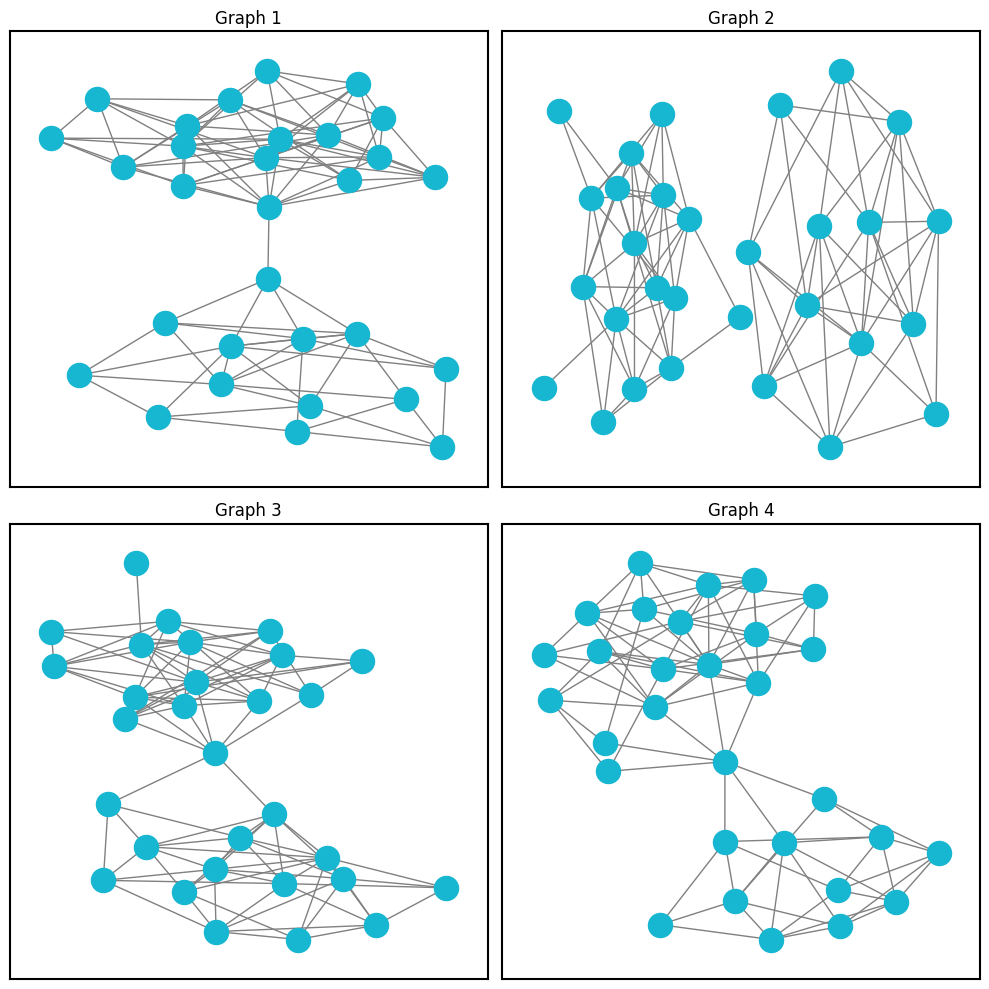

In [78]:
plot_random_graphs(graphs_sampled2, 4)

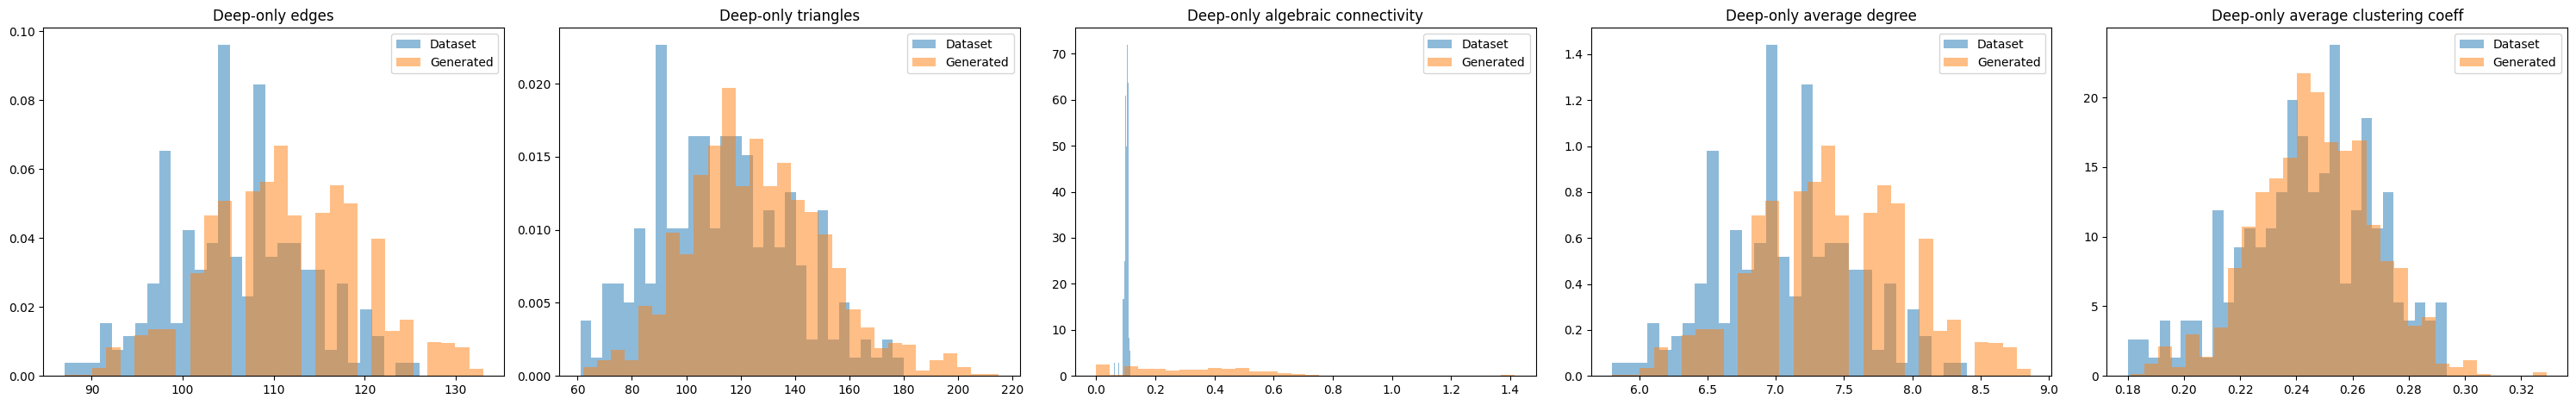

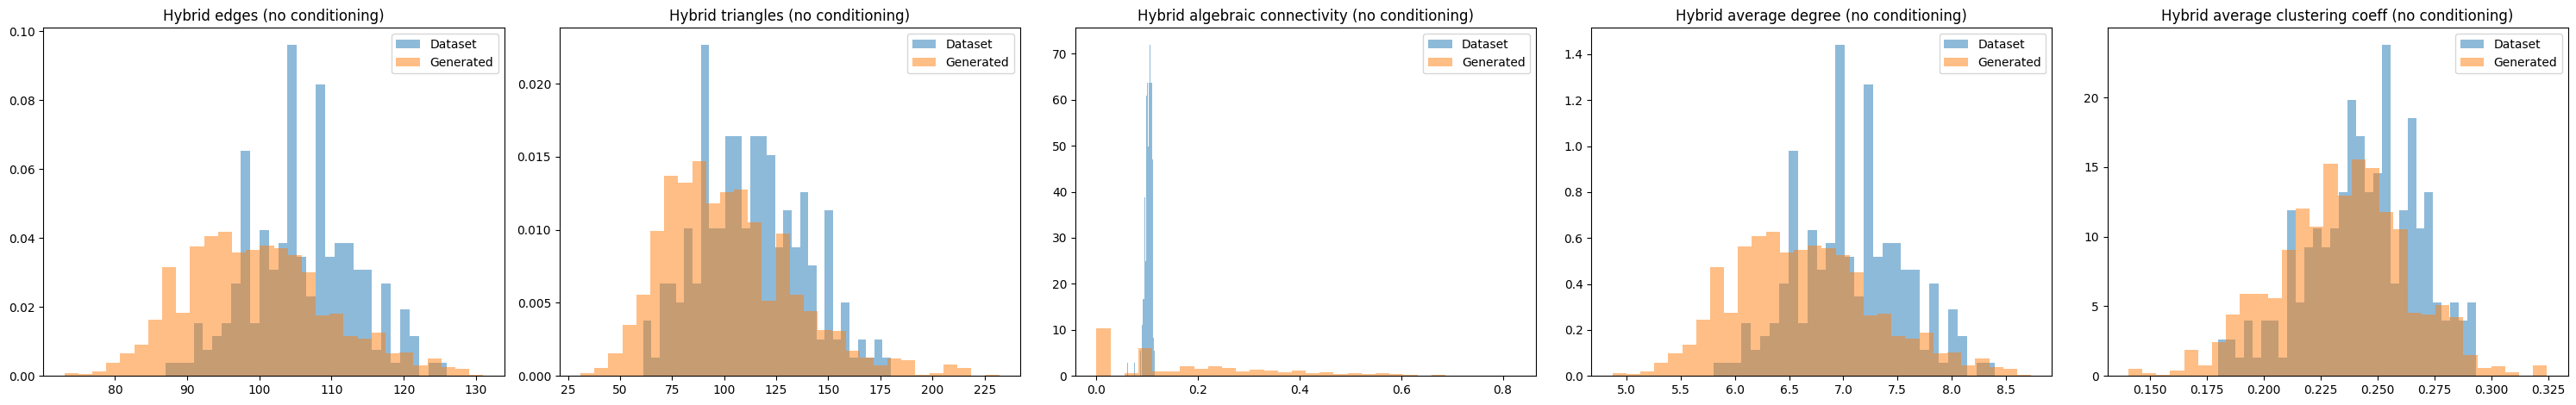

In [74]:
generated_obs2 = [measurer.observables(g) for g in graphs_sampled2]
hist_obs_samples(only_deep_obs, dataset_obs, obs_labels=['Deep-only edges', 'Deep-only triangles', 'Deep-only algebraic connectivity', 'Deep-only average degree', 'Deep-only average clustering coeff'])
hist_obs_samples(generated_obs2, dataset_obs, obs_labels=['Hybrid edges (no conditioning)', 'Hybrid triangles (no conditioning)', 'Hybrid algebraic connectivity (no conditioning)', 'Hybrid average degree (no conditioning)', 'Hybrid average clustering coeff (no conditioning)'])


---
